In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchsummary import summary
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Convolution neural network with Pytorch

ここでは手書き文字の分類を例に、Pytorchを使った畳み込みニューラルネットワークの実装方法を学ぶ。
mnistデータセットを使って手書き文字の分類を行う以下のニューラルネットワークを例にConvolution neural network (CNN)の構造について解説する。
ここで実装するネットワークの概要図は以下の通りである。

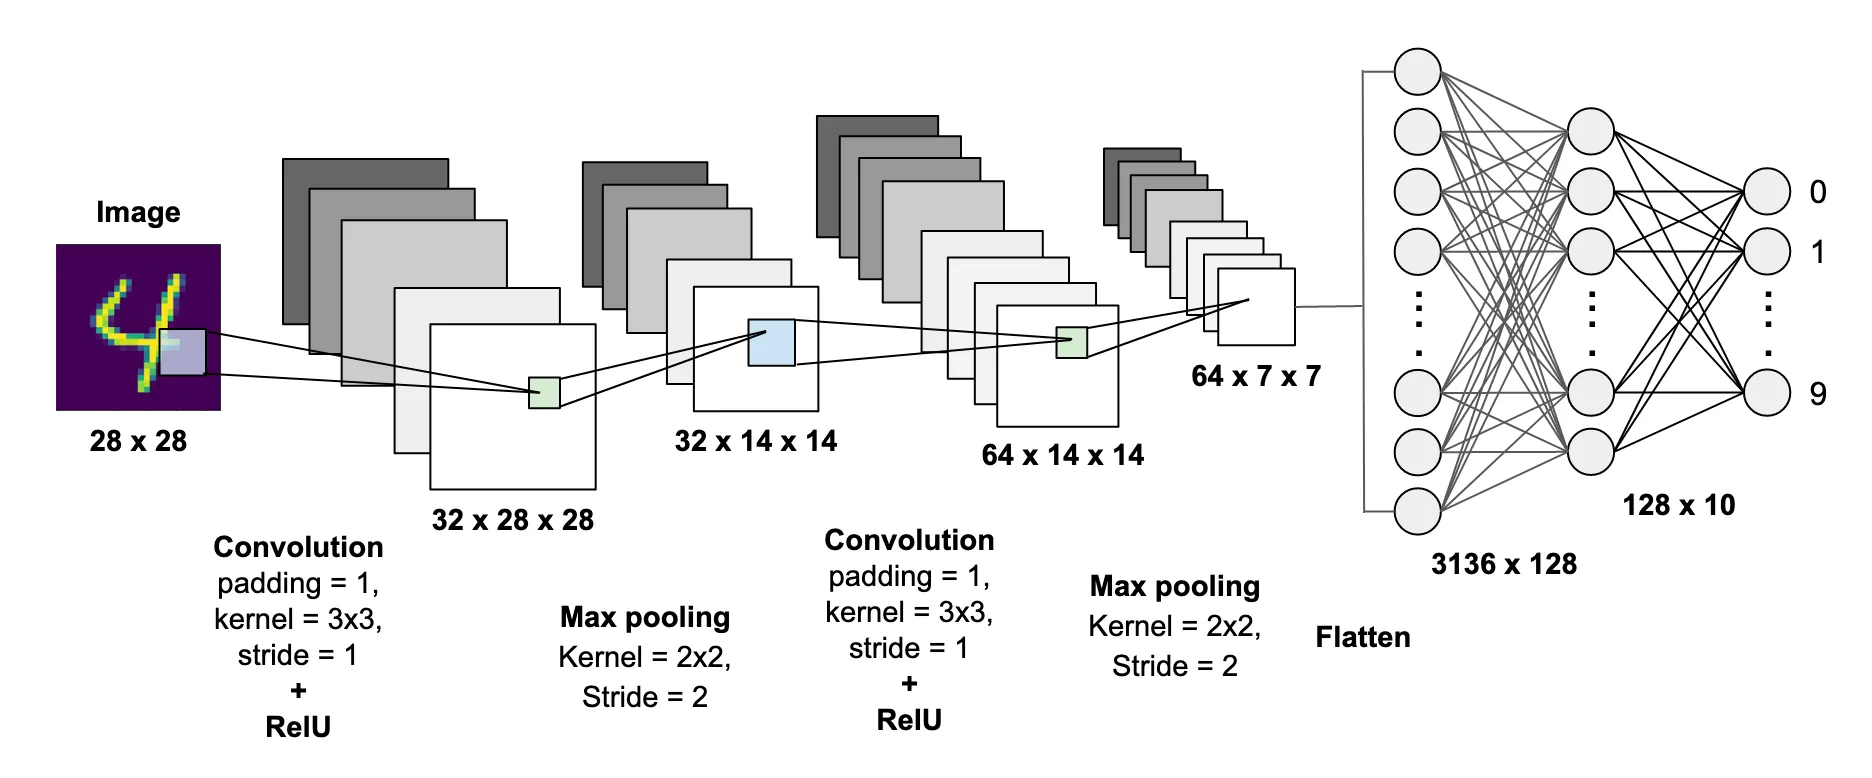
https://towardsdatascience.com/mnist-handwritten-digits-classification-using-a-convolutional-neural-network-cnn-af5fafbc35e9

* 最初の入力は28x28の画像データ。グレースケールの場合, 28x28の行列になっていて,行列の成分が座標(ピクセル)の明るさを表す。

* 畳み込み層は後で説明する畳み込み演算を行う層である。畳み込み演算は画像処理でよく使われる演算で、画像の特徴を抽出するために使われる。

  チャンネル数個(ここでは32個)のフィルタを使って繰り返し畳み込み演算を行う。32枚の"画像"を次の層に渡す。

  Relu関数は活性化関数と呼ばれる関数でピクセル値を、正ならばそのまま、負であればゼロにして返す。

* プーリング層は画像のサイズを縮小する層である。プーリング層では、画像を分割して各領域の最大値を取ることで画像のサイズを縮小する。
　ここでは2x2の領域に分割して最大値を取ることで、画像のサイズが28x28から14x14に縮小される。

* 畳み込み層とプーリング層を繰り返す。畳み込み層のチャンネル数は64に増やしている。

* フラットニング層は画像データ(2次元データ)をベクトルに変換する層である。

* 全結合層は前の層の全てのノードと結合している。難しく聞こえるかもしれないが, 実際の演算は線形変換(行列の掛け算)とRelu関数の適用である。

* 最後の出力層は答えを出力する層である。ここでは0から9の文字を認識するために出力が10個ある。
  10個の出力を各数字のスコアとみなし、スコアの最も高かった数字をがネットワークの予測結果となる。

### 畳み込み演算

畳み込み演算はフィルタと呼ばれる行列(ここでは3x3の行列)を画像の上をスライドさせながら、フィルタの要素と画像の対応する要素の積を取り、その総和を計算する。

実際にはバイアスと呼ばれる定数項を加えて、次のように計算される。

3x3の行列と定数項で10個のパラメータを持つ。

横縦とフィルタを動かしていき、畳み込み演算(+ReLU)の結果を新たな"ピクセル値"とみなす。

入力チャンネルに複数の画像がある場合、それぞれの画像に対して畳み込み演算を行い、その結果を足し合わせる。

その際、 フィルタは入力画像ごとに変える。バイアスは固定。

一つのチャンネルではずっと同じ行列(フィルタ)を画像の様々な場所に畳み込み演算することで、画像の特徴を抽出した(強調された)画像を出力していることに注意しよう。

フィルタを変えながら画像を何度も画像を生成することで、異なる特徴が強調された画像を生成している。

一般に画像データのみだと畳み込み演算の結果出てくる画像は元の画像よりも小さくなるため、画像のサイズを維持したい場合は画像の周りに0を埋める(パディング)操作を行う。

In [4]:
# CNNの定義
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d( 1, 32, kernel_size=(3,3), stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=(3,3), stride=1, padding=1)
        self.dropout1 = nn.Dropout2d(0.25)
        self.dropout2 = nn.Dropout2d(0.5)
        self.fc1 = nn.Linear(64*7*7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = nn.functional.relu(x)
        x = nn.functional.max_pool2d(x, 2)
        x = self.conv2(x)
        x = nn.functional.relu(x)
        x = nn.functional.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = nn.functional.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        output = nn.functional.log_softmax(x, dim=1)
        return output

In [5]:
model = Net()
summary(model,(1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
            Conv2d-2           [-1, 64, 14, 14]          18,496
         Dropout2d-3             [-1, 64, 7, 7]               0
            Linear-4                  [-1, 128]         401,536
         Dropout2d-5                  [-1, 128]               0
            Linear-6                   [-1, 10]           1,290
Total params: 421,642
Trainable params: 421,642
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.31
Params size (MB): 1.61
Estimated Total Size (MB): 1.92
----------------------------------------------------------------


1つ目の畳み込み層のパラメータは32*(3\*3+1) = 320個である。

2つ目の畳み込み層のパラメータは64*(32\*3\*3+1) = 18496個である。

全結合層1つ目のパラメータは7\*7\*64\*128+128 = 401536個である。

全結合層2つ目のパラメータは128\*10+10 = 1290個である。

実際は上の通りパラメータの数を数えてくれるので自分で数える必要はない。

# CNNを学習させる

### データの読み込みと整形処理

In [10]:
# Transformations to apply to the images
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Download and load the training and test datasets
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1000, shuffle=False)

# Function to load and preprocess the custom image
def preprocess_image(image_path):
    image = Image.open(image_path).convert('L')  # Convert to grayscale
    image = image.resize((28, 28))  # Resize to 28x28
    image = np.array(image)
    image = (image - 0.1307) / 0.3081  # Normalize
    image = np.expand_dims(image, axis=0)  # Add channel dimension
    image = np.expand_dims(image, axis=0)  # Add batch dimension
    image = torch.tensor(image, dtype=torch.float32)  # Convert to tensor
    return image

### ロス関数と最適化の定義

lrは学習率である。大きいほど計算は早くなるが、収束しないことがある。小さいほど計算は遅くなるが、収束することが多い。

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

学習済みのネットワークを読み込んで再度学習を進める場合は次のセルをアンコメントアウトして実行する

In [12]:
#load the model
#model.load_state_dict(torch.load('mnist_cnn.pth'))

### 学習過程の実装

In [15]:
# Training loop
def train(model, device, train_loader, optimizer, epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx % 100 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} ({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}')

# Testing loop with plotting
def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0
    test_images = []
    test_predictions = []
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            test_images.extend(data.cpu().numpy())
            test_predictions.extend(pred.cpu().numpy())

    test_loss /= len(test_loader.dataset)
    print(f'\nTest set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} ({100. * correct / len(test_loader.dataset):.0f}%)\n')
    
    #各エポックでの正答率が見たい場合はここをアンコメントアウトする
    #ここから
    #fig, axes = plt.subplots(3, 3, figsize=(9, 9))
    #axes = axes.flatten()
    #for i, ax in enumerate(axes):
    #    img = test_images[i][0]
    #    ax.imshow(img, cmap='gray')
    #    ax.set_title(f'Prediction: {test_predictions[i][0]}')
    #    ax.axis('off')
    #plt.tight_layout()
    #ここまで


### 学習の実行

エポック数は学習データを何周するかを決める。

Using device: mps
Train Epoch: 1 [0/60000 (0%)]	Loss: 0.034321
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.073543
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.024132
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.013829
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.108133
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.005841
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.006711
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.011029
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.017531
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.006642

Test set: Average loss: 0.0000, Accuracy: 9923/10000 (99%)

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.035644
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.081790
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.087409
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.003806
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.041035
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.001533
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.010820
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.016720
Train Epoch: 2 [51200/60000 (85%)

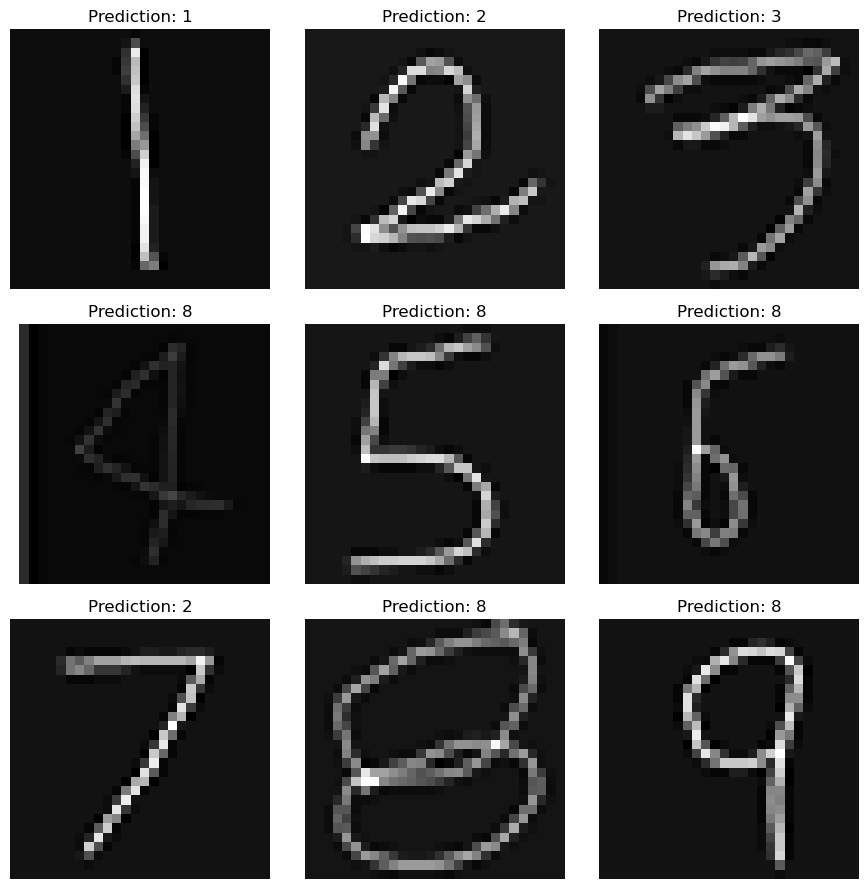

In [16]:
# Function to make a prediction on a custom image
def predict_custom_image(model, device, image_path):
    model.eval()
    image = preprocess_image(image_path).to(device)
    with torch.no_grad():
        output = model(image)
        pred = output.argmax(dim=1, keepdim=True)
        return pred.item()

# Train and test the model

#google colaraboratoryの場合などcudaが使える場合は上を使う
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

print(f'Using device: {device}')
model.to(device)

for epoch in range(1, 10):
    train(model, device, train_loader, optimizer, epoch)
    test(model, device, test_loader)

#学習結果を保存したい場合は以下をアンコメントアウトする
#torch.save(model.state_dict(), 'mnist_cnn.pth')


# Plotting some of the test images with their predictions
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
axes = axes.flatten()
for i, ax in enumerate(axes):
    custom_image_path = './test_'+format(i+1)+'.png'  # Replace with your image path
    image = Image.open(custom_image_path).convert('L')  # Convert to grayscale
    image = image.resize((28, 28))  # Resize to 28x28
    image = np.array(image)
    predicted_label = predict_custom_image(model, device, custom_image_path)
    ax.imshow(image, cmap='gray')
    ax.set_title(f'Prediction: {predicted_label}')
    ax.axis('off')
plt.tight_layout()
plt.show()


# 課題I

* 学習率を大きくしすぎると学習が進まなくなる(lossが下がらない)ことを確認せよ。

* 学習率を元に戻し, エポック数を変えて学習進捗を確認せよ。

# Generative Adversarial Network

次にGANを実装する。GANは生成モデルの一つであり、生成モデルはデータの分布を学習し、新しいデータを生成することができる。